# Visual Classifier — Evaluation
Compares the **original** `facebook/convnextv2-large-22k-224` model against the
**fine-tuned** version (loaded from `./fine_tuned_model_delta/run_01_zitacron_weight_delta.pt`)
on the test split of `Zitacron/real-vs-ai-corpus`.

> ⚠️ **Pre-requisite:** Run `visual_classifier_finetuning.ipynb` first to train the model
> and generate `./fine_tuned_model_delta/run_01_zitacron_weight_delta.pt`.

## 0. Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

import torch
from datasets import load_dataset
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from tqdm.notebook import tqdm
from visual_classifier import VisualClassifier

## 1. Load the Test Dataset

In [2]:
from two_stage_finetuning import build_zitacron_subset

zitacron_ds = build_zitacron_subset(
    total_train=10000,
    total_val=2000,
    total_test=2000,
    seed=42,
)
test_dataset = zitacron_ds["test"]

print(f"Loaded {len(test_dataset)} test examples from Zitacron.")

📦  Loading cached Zitacron subset from data/zitacron_subset…
Loaded 2000 test examples from Zitacron.


## 2. Load Both Models

In [3]:
print("Loading original model...")
original_classifier = VisualClassifier(model_name_or_path="facebook/convnextv2-large-22k-224")
print("Original model ready.")

Loading original model...


Loading weights:   0%|          | 0/380 [00:00<?, ?it/s]

Original model ready.


In [4]:
print("Loading fine-tuned model from local weight delta...")
fine_tuned_classifier = VisualClassifier(
    model_name_or_path="facebook/convnextv2-large-22k-224",
    delta_path="./fine_tuned_model_delta/run_01_zitacron_weight_delta.pt",
)
print("Fine-tuned model ready.")

Loading fine-tuned model from local weight delta...


Loading weights:   0%|          | 0/380 [00:00<?, ?it/s]

Applying weight delta from './fine_tuned_model_delta/run_01_zitacron_weight_delta.pt'...
Delta applied successfully.
Fine-tuned model ready.


## 3. Quick Sanity Check — Single Sample

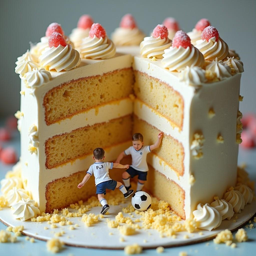

Ground Truth: AI Generated
Original model:   {'prediction': 'AI Generated', 'confidence': 0.7051, 'raw_label': 'bakery, bakeshop, bakehouse', 'all_scores': {'tench, Tinca tinca': 0.0001, 'goldfish, Carassius auratus': 0.0002, 'great white shark, white shark, man-eater, man-eating shark, Carcharodon carcharias': 0.0001, 'tiger shark, Galeocerdo cuvieri': 0.0002, 'hammerhead, hammerhead shark': 0.0001, 'electric ray, crampfish, numbfish, torpedo': 0.0001, 'stingray': 0.0001, 'cock': 0.0002, 'hen': 0.0002, 'ostrich, Struthio camelus': 0.0001, 'brambling, Fringilla montifringilla': 0.0001, 'goldfinch, Carduelis carduelis': 0.0001, 'house finch, linnet, Carpodacus mexicanus': 0.0, 'junco, snowbird': 0.0001, 'indigo bunting, indigo finch, indigo bird, Passerina cyanea': 0.0001, 'robin, American robin, Turdus migratorius': 0.0001, 'bulbul': 0.0001, 'jay': 0.0, 'magpie': 0.0001, 'chickadee': 0.0, 'water ouzel, dipper': 0.0, 'kite': 0.0001, 'bald eagle, American eagle, Haliaeetus leucocephalus'

In [5]:
from IPython.display import display
import io
from PIL import Image

label_map = {0: 'Real', 1: 'AI Generated'}

# Since test_dataset is a streaming/iterable dataset, get the first element via iteration
sample_item = next(iter(test_dataset))
sample_image = sample_item['image']
if isinstance(sample_image, bytes):
    sample_image = Image.open(io.BytesIO(sample_image))
sample_image = sample_image.convert('RGB')

sample_label = label_map.get(sample_item['label'], 'Unknown')

display(sample_image.resize((256, 256)))
print(f"Ground Truth: {sample_label}")
print(f"Original model:   {original_classifier.predict(sample_image)}")
print(f"Fine-tuned model: {fine_tuned_classifier.predict(sample_image)}")

## 4. Full Test-Set Evaluation
Runs inference for both models across the entire test split.

In [6]:
# Set a max sample limit if you want to evaluate faster
# Since test_dataset is a streaming/iterable dataset, we cannot use len() or direct indexing.
# We will iterate directly and stop after num_samples.
# num_samples = 20000
num_samples = 200

import io
from PIL import Image

orig_true_labels = []
orig_pred_labels = []

ft_true_labels = []
ft_pred_labels = []

count = 0
for item in tqdm(test_dataset, total=num_samples, desc="Evaluating both models"):
    if count >= num_samples:
        break
    
    img = item['image']
    if isinstance(img, bytes):
        img = Image.open(io.BytesIO(img))
    if img.mode != 'RGB':
        img = img.convert('RGB')

    true_label = label_map.get(item['label'], 'Unknown')

    # Original model
    orig_pred = original_classifier.predict(img)['prediction']
    orig_true_labels.append(true_label)
    orig_pred_labels.append(orig_pred)

    # Fine-tuned model
    ft_pred = fine_tuned_classifier.predict(img)['prediction']
    ft_true_labels.append(true_label)
    ft_pred_labels.append(ft_pred)
    
    count += 1

print("Evaluation complete.")

Evaluating both models:   0%|          | 0/200 [00:00<?, ?it/s]

Evaluation complete.


## 5. Results — Original Model

In [7]:
print("=== Original Model ===")
print("\nClassification Report:")
print(classification_report(orig_true_labels, orig_pred_labels))

print("Confusion Matrix (rows=True, cols=Predicted):")
print(confusion_matrix(orig_true_labels, orig_pred_labels, labels=["Real", "AI Generated"]))

=== Original Model ===

Classification Report:
              precision    recall  f1-score   support

AI Generated       0.52      1.00      0.68       103
        Real       0.00      0.00      0.00        97

    accuracy                           0.52       200
   macro avg       0.26      0.50      0.34       200
weighted avg       0.27      0.52      0.35       200

Confusion Matrix (rows=True, cols=Predicted):
[[  0  97]
 [  0 103]]


## 6. Results — Fine-Tuned Model

In [8]:
print("=== Fine-Tuned Model ===")
print("\nClassification Report:")
print(classification_report(ft_true_labels, ft_pred_labels))

print("Confusion Matrix (rows=True, cols=Predicted):")
print(confusion_matrix(ft_true_labels, ft_pred_labels, labels=["Real", "AI Generated"]))

=== Fine-Tuned Model ===

Classification Report:
              precision    recall  f1-score   support

AI Generated       0.52      1.00      0.68       103
        Real       0.00      0.00      0.00        97

    accuracy                           0.52       200
   macro avg       0.26      0.50      0.34       200
weighted avg       0.27      0.52      0.35       200

Confusion Matrix (rows=True, cols=Predicted):
[[  0  97]
 [  0 103]]


## 7. Side-by-Side Accuracy Comparison

In [9]:
orig_acc = accuracy_score(orig_true_labels, orig_pred_labels)
ft_acc   = accuracy_score(ft_true_labels,   ft_pred_labels)

print(f"Original model accuracy : {orig_acc:.4f} ({orig_acc*100:.2f}%)")
print(f"Fine-tuned model accuracy: {ft_acc:.4f} ({ft_acc*100:.2f}%)")
print(f"Improvement             : {(ft_acc - orig_acc)*100:+.2f} pp")

Original model accuracy : 0.5150 (51.50%)
Fine-tuned model accuracy: 0.5150 (51.50%)
Improvement             : +0.00 pp


## 8. Test Images

In [10]:
from PIL import Image
import IPython.display as display_lib

def test_custom_image(image_path):
    print(f"Testing image: {image_path}")
    try:
        image = Image.open(image_path)
    except Exception as e:
        print(f"Error loading image: {e}")
        return
        
    # Make prediction using the fine-tuned model
    result = fine_tuned_classifier.predict(image)
    
    print("\n--- Results ---")
    print(f"Prediction: {result['prediction']}")
    print(f"Confidence: {result['confidence']*100:.2f}%")
    print(f"Raw Label:  {result['raw_label']}")
    print(f"All Scores: {result['all_scores']}")
    
    # Display the image scaled down for the notebook
    image.thumbnail((400, 400))
    display_lib.display(image)

Testing image: ../../data/sample_images/real-metadata.jpeg

--- Results ---
Prediction: AI Generated
Confidence: 90.25%
Raw Label:  tench, tinca tinca
All Scores: {'tench, Tinca tinca': 0.9025, 'goldfish, Carassius auratus': 0.0029, 'great white shark, white shark, man-eater, man-eating shark, Carcharodon carcharias': 0.0001, 'tiger shark, Galeocerdo cuvieri': 0.0001, 'hammerhead, hammerhead shark': 0.0001, 'electric ray, crampfish, numbfish, torpedo': 0.0001, 'stingray': 0.0001, 'cock': 0.0001, 'hen': 0.0001, 'ostrich, Struthio camelus': 0.0001, 'brambling, Fringilla montifringilla': 0.0001, 'goldfinch, Carduelis carduelis': 0.0001, 'house finch, linnet, Carpodacus mexicanus': 0.0001, 'junco, snowbird': 0.0001, 'indigo bunting, indigo finch, indigo bird, Passerina cyanea': 0.0001, 'robin, American robin, Turdus migratorius': 0.0001, 'bulbul': 0.0001, 'jay': 0.0001, 'magpie': 0.0001, 'chickadee': 0.0001, 'water ouzel, dipper': 0.0001, 'kite': 0.0001, 'bald eagle, American eagle, Haliae

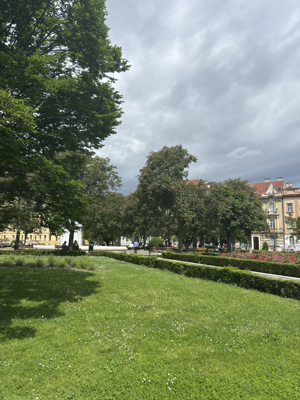

In [14]:
image_path = "../../data/sample_images/real-metadata.jpeg"
test_custom_image(image_path)

In [12]:
image_path = "../../data/sample_images/test_2.png"
test_custom_image(image_path)

Testing image: ../../data/sample_images/test_2.png
Error loading image: [Errno 2] No such file or directory: '../../data/sample_images/test_2.png'


In [13]:
image_path = "../../data/sample_images/test_3.png"
test_custom_image(image_path)

Testing image: ../../data/sample_images/test_3.png
Error loading image: [Errno 2] No such file or directory: '../../data/sample_images/test_3.png'
